<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/Hw_2/Practical_2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green">Prof. Glen Nwaila and Dr. Steven Zhang
</span>

# <span style="color:blue">Practical 2: More Exploratory Data Analysis
</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/Hw_2/Imputed_merged_chem.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0.1,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr,Imputed Old Zn,Imputed Old Cu,Imputed Old Ni,Imputed Old Co,Imputed Old Mn,Imputed Old Fe,Imputed Old F,Imputed Old Hg,Imputed Old U,Imputed New Ag,Imputed New Al,Imputed New Ba,Imputed New Be,Imputed New Ca,Imputed New Cd,Imputed New Ce,Imputed New Co,Imputed New Cr,Imputed New Cs,Imputed New Cu,Imputed New Dy,Imputed New Er,Imputed New Eu,Imputed New Fe,Imputed New Ga,Imputed New Gd,Imputed New Hg,Imputed New Ho,Imputed New K,Imputed New La,Imputed New Li,Imputed New Lu,Imputed New Mg,Imputed New Mn,Imputed New Mo,Imputed New Na,Imputed New Nb,Imputed New Nd,Imputed New Ni,Imputed New P,Imputed New Pb,Imputed New Pr,Imputed New Rb,Imputed New S,Imputed New Sc,Imputed New Se,Imputed New Sm,Imputed New Sr,Imputed New Tb,Imputed New Th,Imputed New Ti,Imputed New Tl,Imputed New Tm,Imputed New U,Imputed New V,Imputed New Y,Imputed New Yb,Imputed New Zn,Imputed New Zr,geometry
0,0,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23.0,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9,40.0,38.0,43.0,10.0,70.0,1.00,85.0,40.0,0.3,57.0,2.89,81.5,0.200000,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,46.0,0.23,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,2.84,1.6,0.25,2.3,0.7,1.90,41.0,0.20,0.8,0.021,0.03,0.10,0.3,31.0,6.04,0.64,44.0,0.9,POINT (-62.0190714 54.9890932)
1,1,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33.0,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0,40.0,44.0,35.0,8.0,80.0,1.90,80.0,70.0,0.5,106.0,3.22,26.0,0.180762,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,66.0,0.20,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,2.61,1.6,0.30,2.3,1.3,1.76,31.3,0.19,0.8,0.021,0.03,0.08,0.3,45.0,5.65,0.49,45.1,1.0,POINT (-62.0305772 54.9753817)
2,2,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8,46.0,30.0,34.0,8.0,80.0,0.70,90.0,50.0,0.6,59.0,2.34,49.9,0.100000,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,51.0,0.28,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,3.22,1.7,0.27,2.2,0.7,2.20,40.9,0.22,0.7,0.023,0.04,0.09,0.3,17.0,7.19,0.64,51.4,0.8,POINT (-62.0449127 54.9763308)
3,3,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,0

### Remember we started looking at variable domain relationships in data last practical?

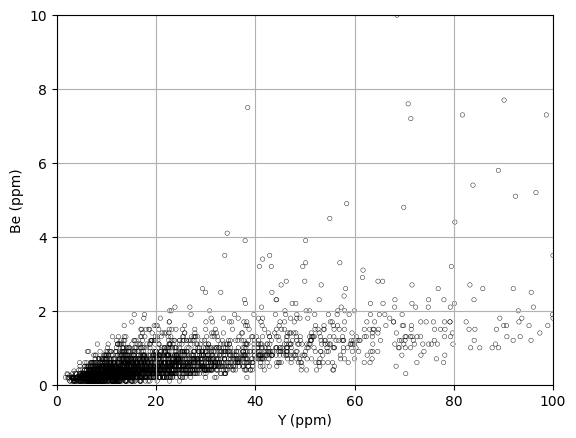

In [3]:
# We can understand more about the nature of the correlation between "Y" and "Be"
# Let's try a scatter plot

plt.scatter(df['Imputed New Y'], df['Imputed New Be'], s = 10, edgecolor = 'k', facecolor = 'none', linewidth = 0.3)

plt.xlabel('Y (ppm)')
plt.ylabel('Be (ppm)')

plt.xlim([0, 100])
plt.ylim([0, 10])

plt.grid()

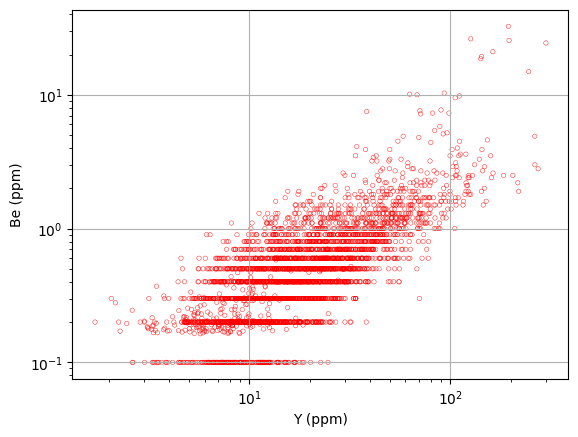

In [4]:

# Let's try a log plot

plt.scatter(df['Imputed New Y'], df['Imputed New Be'], s = 10, edgecolor = 'red', facecolor = 'none', linewidth = 0.3)


#plt.scatter(df['New Y'], df['New Be'], s = 10, edgecolor = 'blue', facecolor = 'none', linewidth = 0.3)


plt.xscale('log') #this sets the x-axis to log scale
plt.yscale('log') #this sets the y-axis to log scale

plt.xlabel('Y (ppm)')
plt.ylabel('Be (ppm)')

plt.grid()

### Notice how the log transform made the trend more obvious and linear? Is this true for other relationships as well?

#### Let's do a quick correlation analysis between Mn and Fe as well

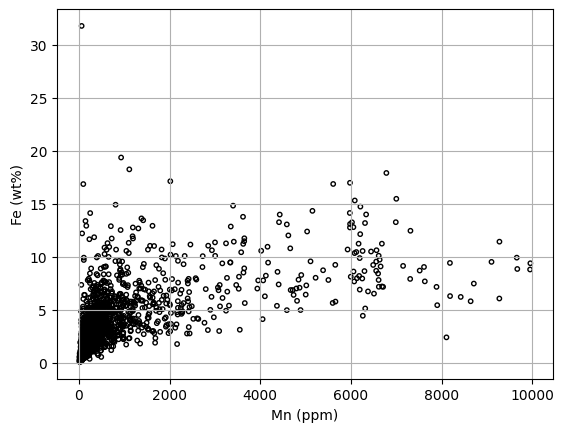

In [5]:
plt.scatter(df['Imputed New Mn'], df['Imputed New Fe'], s = 10, facecolor = 'none', edgecolor = 'k')


plt.xlabel('Mn (ppm)')
plt.ylabel('Fe (wt%)')

plt.grid()

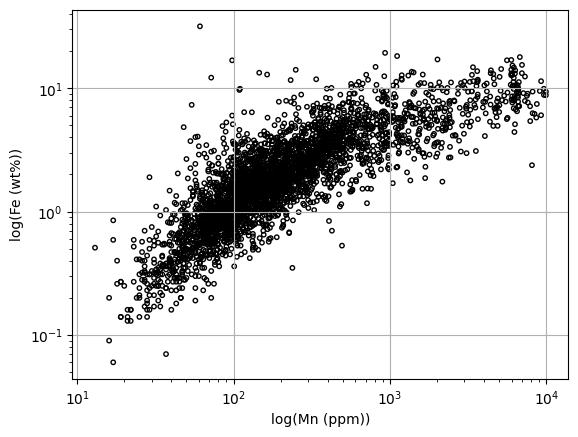

In [6]:
plt.scatter(df['Imputed New Mn'], df['Imputed New Fe'], s = 10, facecolor = 'none', edgecolor = 'k')
plt.xscale('log') #this sets the x-axis to log scale
plt.yscale('log') #this sets the y-axis to log scale


plt.xlabel('log(Mn (ppm))')
plt.ylabel('log(Fe (wt%))')

plt.grid()

#### What do we observe in this figure? Let's discuss.

#### Let's also reconstruct some lists of elements that we can use to quickly refer to each column in the dataframe

In [7]:
imputed_elems = [element for element in df.columns if 'Imputed New' in element]
imputed_elems

['Imputed New Ag',
 'Imputed New Al',
 'Imputed New Ba',
 'Imputed New Be',
 'Imputed New Ca',
 'Imputed New Cd',
 'Imputed New Ce',
 'Imputed New Co',
 'Imputed New Cr',
 'Imputed New Cs',
 'Imputed New Cu',
 'Imputed New Dy',
 'Imputed New Er',
 'Imputed New Eu',
 'Imputed New Fe',
 'Imputed New Ga',
 'Imputed New Gd',
 'Imputed New Hg',
 'Imputed New Ho',
 'Imputed New K',
 'Imputed New La',
 'Imputed New Li',
 'Imputed New Lu',
 'Imputed New Mg',
 'Imputed New Mn',
 'Imputed New Mo',
 'Imputed New Na',
 'Imputed New Nb',
 'Imputed New Nd',
 'Imputed New Ni',
 'Imputed New P',
 'Imputed New Pb',
 'Imputed New Pr',
 'Imputed New Rb',
 'Imputed New S',
 'Imputed New Sc',
 'Imputed New Se',
 'Imputed New Sm',
 'Imputed New Sr',
 'Imputed New Tb',
 'Imputed New Th',
 'Imputed New Ti',
 'Imputed New Tl',
 'Imputed New Tm',
 'Imputed New U',
 'Imputed New V',
 'Imputed New Y',
 'Imputed New Yb',
 'Imputed New Zn',
 'Imputed New Zr']

#### Let's try a common geochemical data transformation

array([[<Axes: xlabel='Imputed New Zr', ylabel='Imputed New Zr'>,
        <Axes: xlabel='Imputed New U', ylabel='Imputed New Zr'>,
        <Axes: xlabel='Imputed New Mo', ylabel='Imputed New Zr'>,
        <Axes: xlabel='Imputed New Fe', ylabel='Imputed New Zr'>,
        <Axes: xlabel='Imputed New Co', ylabel='Imputed New Zr'>,
        <Axes: xlabel='Imputed New Mn', ylabel='Imputed New Zr'>],
       [<Axes: xlabel='Imputed New Zr', ylabel='Imputed New U'>,
        <Axes: xlabel='Imputed New U', ylabel='Imputed New U'>,
        <Axes: xlabel='Imputed New Mo', ylabel='Imputed New U'>,
        <Axes: xlabel='Imputed New Fe', ylabel='Imputed New U'>,
        <Axes: xlabel='Imputed New Co', ylabel='Imputed New U'>,
        <Axes: xlabel='Imputed New Mn', ylabel='Imputed New U'>],
       [<Axes: xlabel='Imputed New Zr', ylabel='Imputed New Mo'>,
        <Axes: xlabel='Imputed New U', ylabel='Imputed New Mo'>,
        <Axes: xlabel='Imputed New Mo', ylabel='Imputed New Mo'>,
        <Axes: xl

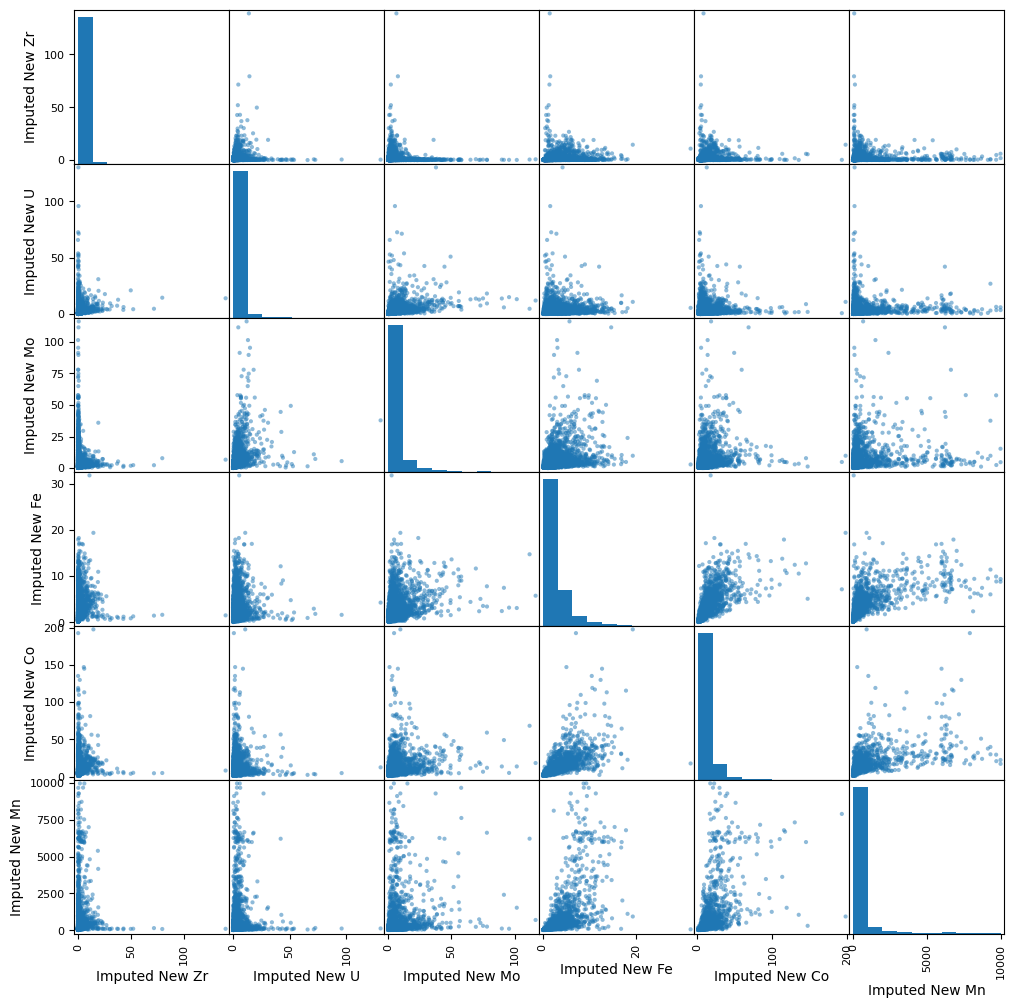

In [8]:
plotting_elems = ['Imputed New Zr', 'Imputed New U', 'Imputed New Mo',
                  'Imputed New Fe', 'Imputed New Co', 'Imputed New Mn']
pd.plotting.scatter_matrix(df[plotting_elems], figsize = (12, 12))

#### This looks horribly uninformative - why is that? Because the data is closed.

![Aitchison-simplex.jpg](attachment:Aitchison-simplex.jpg)

Aitchison, J., 1984. The statistical analysis of geochemical compositions. Mathematical Geology, 16(6):531-564.

Aitchison, J., 1986. The Statistical Analysis of Compositional data. Chapman and Hall, London, U.K., 416 p.

Aitchison, J. and Egozcue, J.J., 2005. Compositional data analysis; where are we and where should we be heading. Mathematical Geology, 37(7):829-850.

Buccianti, A., Mateu-Figueras, G, and Pawlowsky-Glahn, V. (eds.), 2006. Compositional data analysis in the geosciences: from theory to practice. The Geological Society Publishing House, Bath, U.K. Special Publication 264, 224 p.

Janousek, V., Farrow, C.M. and Erban, V., 2006. Interpretation of whole-rock geochemical data in igneous geochemistry introducing Geochemical Data Toolkit (GCDkit). Journal of Petrology, 47(6):1255-1259.

Reimann, C., Filzmoser, P., Garrett, R. and Dutter, R., 2008. Statistical Data Analysis Explained: Applied Environmental Statistics with R. Wiley, 362 p.

#### Let's discuss what this means

In [9]:
# So the way to break out of closure (although still not quite fully Euclidean) is to apply a log-ratio transform
# First we'll need to gather all elements within the same dataset, we'll use the new ones for now
transform_elems = imputed_elems
transform_elems

['Imputed New Ag',
 'Imputed New Al',
 'Imputed New Ba',
 'Imputed New Be',
 'Imputed New Ca',
 'Imputed New Cd',
 'Imputed New Ce',
 'Imputed New Co',
 'Imputed New Cr',
 'Imputed New Cs',
 'Imputed New Cu',
 'Imputed New Dy',
 'Imputed New Er',
 'Imputed New Eu',
 'Imputed New Fe',
 'Imputed New Ga',
 'Imputed New Gd',
 'Imputed New Hg',
 'Imputed New Ho',
 'Imputed New K',
 'Imputed New La',
 'Imputed New Li',
 'Imputed New Lu',
 'Imputed New Mg',
 'Imputed New Mn',
 'Imputed New Mo',
 'Imputed New Na',
 'Imputed New Nb',
 'Imputed New Nd',
 'Imputed New Ni',
 'Imputed New P',
 'Imputed New Pb',
 'Imputed New Pr',
 'Imputed New Rb',
 'Imputed New S',
 'Imputed New Sc',
 'Imputed New Se',
 'Imputed New Sm',
 'Imputed New Sr',
 'Imputed New Tb',
 'Imputed New Th',
 'Imputed New Ti',
 'Imputed New Tl',
 'Imputed New Tm',
 'Imputed New U',
 'Imputed New V',
 'Imputed New Y',
 'Imputed New Yb',
 'Imputed New Zn',
 'Imputed New Zr']

In [ ]:
# we need to pick out the major elements because their units are different
# this can be automated with a proper metadata file that has an attribute that specifies the unit given the attribute name
major_elems = ['Imputed New Al', 'Imputed New Ca', 'Imputed New Fe', 'Imputed New K', 'Imputed New Mg',
               'Imputed New Na', 'Imputed New P', 'Imputed New S', 'Imputed New Ti']

In [10]:
df[imputed_elems] = df[imputed_elems]*10000 #convert from wt% to ppm

In [11]:

from scipy.stats import gmean

clr_names = []

for name in transform_elems:

    name_string = 'CLR('+name+')'

    df[name_string] = np.log(df[name]/gmean(df[transform_elems], axis = 1))

    clr_names.append(name_string)

clr_names



['CLR(Imputed New Ag)',
 'CLR(Imputed New Al)',
 'CLR(Imputed New Ba)',
 'CLR(Imputed New Be)',
 'CLR(Imputed New Ca)',
 'CLR(Imputed New Cd)',
 'CLR(Imputed New Ce)',
 'CLR(Imputed New Co)',
 'CLR(Imputed New Cr)',
 'CLR(Imputed New Cs)',
 'CLR(Imputed New Cu)',
 'CLR(Imputed New Dy)',
 'CLR(Imputed New Er)',
 'CLR(Imputed New Eu)',
 'CLR(Imputed New Fe)',
 'CLR(Imputed New Ga)',
 'CLR(Imputed New Gd)',
 'CLR(Imputed New Hg)',
 'CLR(Imputed New Ho)',
 'CLR(Imputed New K)',
 'CLR(Imputed New La)',
 'CLR(Imputed New Li)',
 'CLR(Imputed New Lu)',
 'CLR(Imputed New Mg)',
 'CLR(Imputed New Mn)',
 'CLR(Imputed New Mo)',
 'CLR(Imputed New Na)',
 'CLR(Imputed New Nb)',
 'CLR(Imputed New Nd)',
 'CLR(Imputed New Ni)',
 'CLR(Imputed New P)',
 'CLR(Imputed New Pb)',
 'CLR(Imputed New Pr)',
 'CLR(Imputed New Rb)',
 'CLR(Imputed New S)',
 'CLR(Imputed New Sc)',
 'CLR(Imputed New Se)',
 'CLR(Imputed New Sm)',
 'CLR(Imputed New Sr)',
 'CLR(Imputed New Tb)',
 'CLR(Imputed New Th)',
 'CLR(Imputed New T

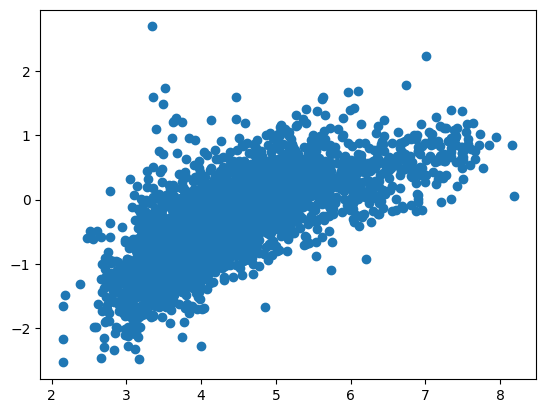

In [12]:
plt.scatter(df['CLR(Imputed New Mn)'], df['CLR(Imputed New Fe)'])

In [13]:
CLR_plotting_elems = ['CLR('+elem+')' for elem in plotting_elems]
CLR_plotting_elems

['CLR(Imputed New Zr)',
 'CLR(Imputed New U)',
 'CLR(Imputed New Mo)',
 'CLR(Imputed New Fe)',
 'CLR(Imputed New Co)',
 'CLR(Imputed New Mn)']

array([[<Axes: xlabel='CLR(Imputed New Zr)', ylabel='CLR(Imputed New Zr)'>,
        <Axes: xlabel='CLR(Imputed New U)', ylabel='CLR(Imputed New Zr)'>,
        <Axes: xlabel='CLR(Imputed New Mo)', ylabel='CLR(Imputed New Zr)'>,
        <Axes: xlabel='CLR(Imputed New Fe)', ylabel='CLR(Imputed New Zr)'>,
        <Axes: xlabel='CLR(Imputed New Co)', ylabel='CLR(Imputed New Zr)'>,
        <Axes: xlabel='CLR(Imputed New Mn)', ylabel='CLR(Imputed New Zr)'>],
       [<Axes: xlabel='CLR(Imputed New Zr)', ylabel='CLR(Imputed New U)'>,
        <Axes: xlabel='CLR(Imputed New U)', ylabel='CLR(Imputed New U)'>,
        <Axes: xlabel='CLR(Imputed New Mo)', ylabel='CLR(Imputed New U)'>,
        <Axes: xlabel='CLR(Imputed New Fe)', ylabel='CLR(Imputed New U)'>,
        <Axes: xlabel='CLR(Imputed New Co)', ylabel='CLR(Imputed New U)'>,
        <Axes: xlabel='CLR(Imputed New Mn)', ylabel='CLR(Imputed New U)'>],
       [<Axes: xlabel='CLR(Imputed New Zr)', ylabel='CLR(Imputed New Mo)'>,
        <Axes: xla

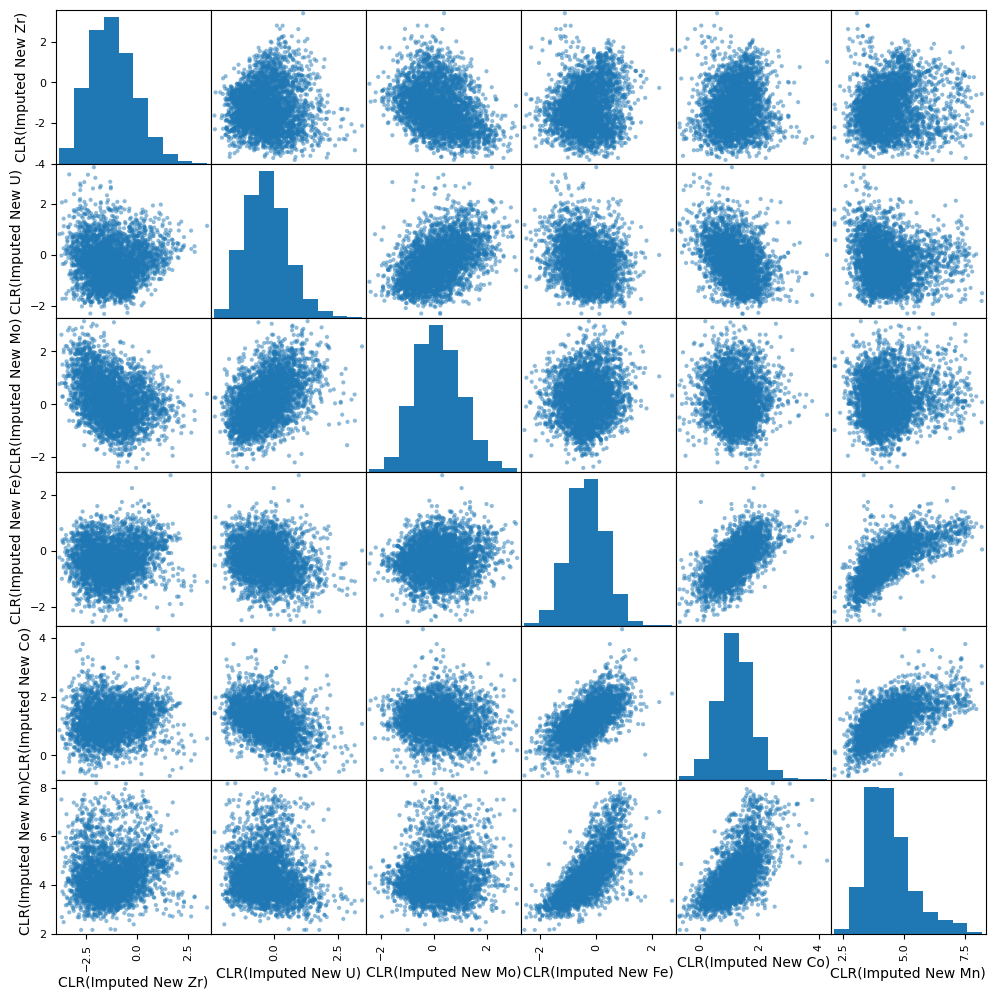

In [14]:
pd.plotting.scatter_matrix(df[CLR_plotting_elems], figsize = (12, 12))

#### So that's much better and correlations can be seen. They look much more like what we did when we manually took logs of data and then plotted them against each other.

In [ ]:
# We will now save our dataframe.
df.to_csv('CLR_Imputed_merged_chem.csv')

### Assignment


#### Explore the relationships between the "Old" and "New" analyses for each of the imputed and CLR-transformed quantities

(1) Check which elements still exist in the imputed new AND imputed old sets.
(2) For each one that still exists in both, do a visualization of the relationship.
(3) Determine the slope and intercept of a linear model fitted to the data, and calculate R-squared of the fit.
(4) Comment on what you see.

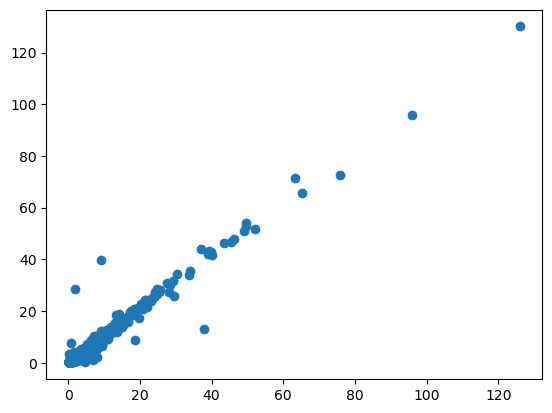

In [ ]:
# Example of a visualization of old U vs. new U - you need to develop this further and fit a line with proper statistics.
plt.scatter(df['Imputed Old U'], df['Imputed New U'])